### План работы

Загружаем данные из файла merged_data.csv со всей необходимой информацией, очищенный от нуллов и выбросов

**1. Изучение различий между городами.**

Расчет по каждому городу:

+ Среднего чека в месяц на пользователя
+ Доли индивидуальных тренировок от общего числа занятий
+ Количества уникальных пользователей

Построение scatterplot, где:
+ Ось X — доля индивидуальных тренировок

+ Ось Y — средний чек

+ Цвет — город

Построение пузырьковой диаграммы (bubble plot), где размер пузырька - это количество уникальных пользователей в городе

**2. Изучение ключевых метрик по возрастным группам** 

Разделим клиентов на три возрастные группы:

+ до 30 лет
+ от 30 до 45 лет
+ старше 45 лет

Для каждой возрастной группы рассчитаем:

+ Среднюю долю индивидуальных тренировок
+ Среднее количество тренировок в месяц
+ Средний месячный чек
+ Общее количество клиентов в группе

Представим результаты в виде таблицы и ответим на вопросы:

+ Как меняется поведение клиентов с возрастом?
+ Какие возрастные группы более склонны к индивидуальным тренировкам?
+ Есть ли возрастная группа с меньшей вовлечённостью, которую стоит дополнительно стимулировать?

**3. Изучение премиального сегмента** 

+ Найдем 10 пользователей с самой высокой совокупной выручкой (LTR) - сумма всех платежей пользователя за весь период.
+ Сохраним их id в формате список
+ Выведем для этих пользователей город, пол, средний чек за месяц, среднее количество тренировок в месяц и количество месяцев, которые они тренировались.

**4. Изучение удержания пользователей после первого месяца тренировок** 

+ Создадим когорту для каждого пользователя — определим месяц их первого визита (min_mon).
+ Рассчитаем индекс когорты (cohort_index), который показывает, какой по счёту месяц после первого визита рассматривается для каждого пользователя.
+ Для каждой когорты и каждого месяца жизни найдем количество уникальных активных пользователей.
+ Построим когортную таблицу удержания, которая показывает, какая доля пользователей осталась активной в каждом следующем месяце после первого визита.
+ Визуализация результатов в виде тепловой карты с retention за первые 4 месяца для каждой когорты.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [112]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### Задача 1. Различия по городам

In [8]:
pay_user = df.groupby(['id_user', 'city']).agg({'mon' : 'count', 'sum_total' : 'sum', 'cnt_indiv' : 'sum', 'cnt_total' : 'sum'}).reset_index()\
.rename(columns = {'mon' : 'months'})
pay_user.head()

,id_user,city,months,sum_total,cnt_indiv,cnt_total
0,1000,СПб,9,58600,33,33
1,1001,Москва,11,124800,23,129
2,1002,Москва,11,166000,64,128
3,1004,Екатеринбург,9,32000,18,18
4,1005,СПб,2,12600,7,7


In [10]:
pay_user['avg_check_per_mon'] = pay_user['sum_total'] / pay_user['months']
pay_user['share_indiv'] = pay_user['cnt_indiv'] / pay_user['cnt_total']
pay_user.head()

,id_user,city,months,sum_total,cnt_indiv,cnt_total,avg_check_per_mon,share_indiv
0,1000,СПб,9,58600,33,33,6511.111111,1.000000
1,1001,Москва,11,124800,23,129,11345.454545,0.178295
2,1002,Москва,11,166000,64,128,15090.909091,0.500000
3,1004,Екатеринбург,9,32000,18,18,3555.555556,1.000000
4,1005,СПб,2,12600,7,7,6300.000000,1.000000


In [12]:
city_stats = pay_user.groupby('city').agg({'id_user' : 'nunique', 'avg_check_per_mon' : 'mean',\
                                          'share_indiv' : 'mean'}).reset_index().rename (columns = {'id_user' : 'nusers'})
city_stats

,city,nusers,avg_check_per_mon,share_indiv
0,Екатеринбург,128,6735.819862,0.308108
1,Казань,127,6698.701412,0.247886
2,Москва,310,7194.958013,0.654638
3,СПб,273,7123.468912,0.333030


In [52]:
city_stats['nusers'] = city_stats['nusers'].astype(float)
print (city_stats['nusers'].dtype)

float64


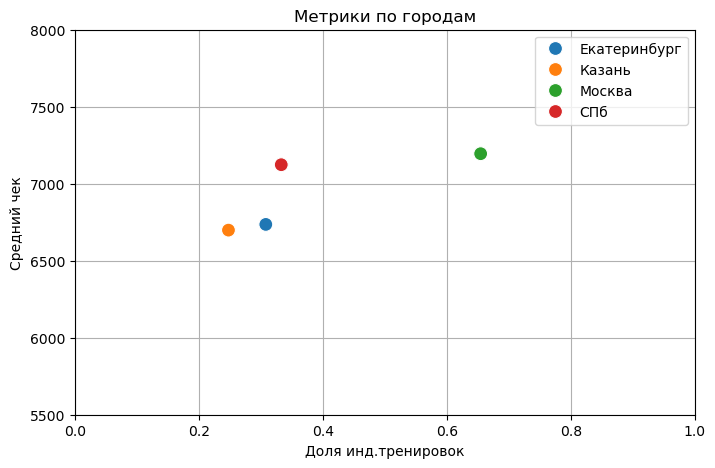

In [14]:
plt.figure(figsize = (8, 5))
plt.xlim (0, 1)
plt.ylim (5500, 8000)
sns.scatterplot(data = city_stats,\
               x = 'share_indiv',\
               y = 'avg_check_per_mon',\
                hue = 'city',\
               s = 100)
plt.xlabel('Доля инд.тренировок')
plt.ylabel('Средний чек')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()


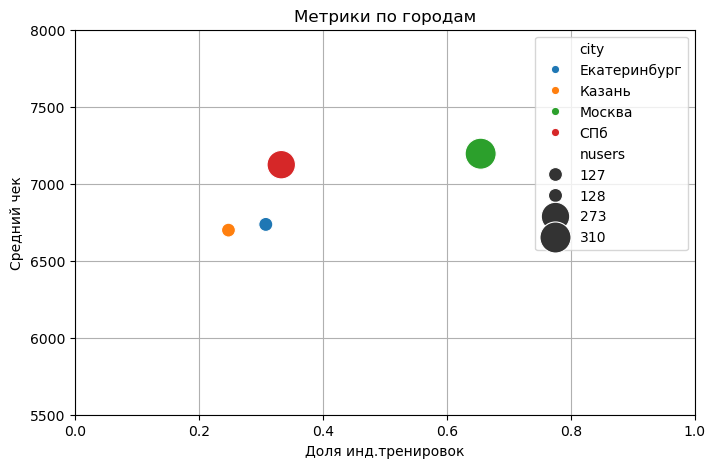

In [16]:
plt.figure(figsize = (8, 5))
plt.xlim (0, 1)
plt.ylim (5500, 8000)
sns.scatterplot(data = city_stats,\
               x = 'share_indiv',\
               y = 'avg_check_per_mon',\
                hue = 'city',\
               size = city_stats['nusers'],\
               sizes=(100, 500)\
               )
plt.xlabel('Доля инд.тренировок')
plt.ylabel('Средний чек')
plt.title('Метрики по городам')
plt.legend()
plt.grid(True)
plt.show()

### Задача 2. сравнение по возрастным когортам

In [18]:
def age_group (age):
    if age <=30:
        return '18-30'
    elif (age >= 31) and (age <= 45):
        return '31-45'
    else:
        return '46+'

In [114]:
df['age_gr'] = df['age'].apply(age_group)
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31-45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45


In [22]:
age_user = df.groupby(['id_user', 'age_gr']).agg({'mon' : 'count', 'sum_total' : 'sum', 'cnt_indiv' : 'sum', 'cnt_total' : 'sum'}).reset_index()\
.rename(columns = {'mon' : 'months'})
age_user.head()

,id_user,age_gr,months,sum_total,cnt_indiv,cnt_total
0,1000,31-45,9,58600,33,33
1,1001,31-45,11,124800,23,129
2,1002,31-45,11,166000,64,128
3,1004,46+,9,32000,18,18
4,1005,31-45,2,12600,7,7


In [24]:
age_user['avg_check_per_mon'] = age_user['sum_total'] / age_user['months']
age_user['share_indiv'] = age_user['cnt_indiv'] / age_user['cnt_total']
age_user['avg_tr_per_mon'] = age_user['cnt_total'] / age_user['months']
age_user.head()

,id_user,age_gr,months,sum_total,cnt_indiv,cnt_total,avg_check_per_mon,share_indiv,avg_tr_per_mon
0,1000,31-45,9,58600,33,33,6511.111111,1.000000,3.666667
1,1001,31-45,11,124800,23,129,11345.454545,0.178295,11.727273
2,1002,31-45,11,166000,64,128,15090.909091,0.500000,11.636364
3,1004,46+,9,32000,18,18,3555.555556,1.000000,2.000000
4,1005,31-45,2,12600,7,7,6300.000000,1.000000,3.500000


In [28]:
age_user['id_user'].nunique()

838

In [26]:
age_segm = age_user.groupby('age_gr').agg({'id_user' : 'nunique',\
                                           'months' : 'mean',\
                                           'avg_check_per_mon' : 'mean',\
                                           'avg_tr_per_mon' : 'mean',\
                                          'share_indiv' : 'mean'}).reset_index().rename(columns = {'id_user' : 'nusers'})
age_segm

,age_gr,nusers,months,avg_check_per_mon,avg_tr_per_mon,share_indiv
0,18-30,278,5.399281,8222.747802,7.290366,0.446690
1,31-45,271,5.343173,7774.985357,7.003930,0.445543
2,46+,289,5.681661,5173.422485,4.737098,0.414714


### Задача 3. Топ-10 пользователей по LTR

In [60]:
user_top10 = df.groupby('id_user').agg(user_ltr = ('sum_total', 'sum')).reset_index().sort_values('user_ltr', ascending = False).head(10)['id_user'].tolist()
user_top10

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [64]:
prem_user = df[df['id_user'].isin (user_top10)].groupby(['id_user', 'city', 'gender', 'age_gr']).\
agg({'mon' : 'count', 'sum_total' : 'sum', 'cnt_indiv' : 'sum', 'cnt_total' : 'sum'}).reset_index()\
.rename(columns = {'mon' : 'months'})
prem_user

,id_user,city,gender,age_gr,months,sum_total,cnt_indiv,cnt_total
0,1002,Москва,male,31-45,11,166000,64,128
1,1013,Москва,male,31-45,11,139800,19,151
2,1029,СПб,female,31-45,8,140000,40,126
3,1153,СПб,male,46+,12,147400,53,118
4,1381,Москва,female,18-30,12,147600,22,159
5,1482,Москва,female,18-30,11,131400,46,110
6,1506,Москва,female,18-30,10,146400,36,138
7,1536,Москва,female,18-30,9,134400,37,125
8,1582,Екатеринбург,male,31-45,8,136200,34,127
9,1657,СПб,male,18-30,10,164200,53,144


In [58]:
prem_user['avg_check'] = prem_user['sum_total'] / prem_user['months']
prem_user['cnt_per_mon'] = prem_user['cnt_total'] / prem_user['months']
prem_user

,id_user,city,gender,months,sum_total,cnt_indiv,cnt_total,avg_check,cnt_per_mon
0,1002,Москва,male,11,166000,64,128,15090.909091,11.636364
1,1013,Москва,male,11,139800,19,151,12709.090909,13.727273
2,1029,СПб,female,8,140000,40,126,17500.000000,15.750000
3,1153,СПб,male,12,147400,53,118,12283.333333,9.833333
4,1381,Москва,female,12,147600,22,159,12300.000000,13.250000
5,1482,Москва,female,11,131400,46,110,11945.454545,10.000000
6,1506,Москва,female,10,146400,36,138,14640.000000,13.800000
7,1536,Москва,female,9,134400,37,125,14933.333333,13.888889
8,1582,Екатеринбург,male,8,136200,34,127,17025.000000,15.875000
9,1657,СПб,male,10,164200,53,144,16420.000000,14.400000


In [66]:
prem_user['city'].value_counts()

city
Москва          6
СПб             3
Екатеринбург    1
Name: count, dtype: int64

In [68]:
prem_user['gender'].value_counts()

gender
male      5
female    5
Name: count, dtype: int64

In [70]:
prem_user['age_gr'].value_counts()

age_gr
18-30    5
31-45    4
46+      1
Name: count, dtype: int64

### Задача 4. Анализ доходимости когорт

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4591 entries, 0 to 4590
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_user    4591 non-null   int64  
 1   mon        4591 non-null   object 
 2   cnt_group  4591 non-null   int64  
 3   cnt_indiv  4591 non-null   int64  
 4   sum_group  4591 non-null   int64  
 5   sum_indiv  4591 non-null   int64  
 6   cnt_total  4591 non-null   int64  
 7   sum_total  4591 non-null   int64  
 8   min_mon    4591 non-null   object 
 9   max_mon    4591 non-null   object 
 10  city       4591 non-null   object 
 11  age        4591 non-null   float64
 12  gender     4591 non-null   object 
 13  age_gr     4591 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 502.3+ KB


In [116]:
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")

In [118]:
df['index_mon'] = df['mon'].dt.month - df['min_mon'].dt.month

In [120]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr,index_mon
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,0
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,1
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45,2
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,3
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,4


In [136]:
cohort_stats = df.groupby(['min_mon', 'index_mon']).agg(active_users = ('id_user', 'nunique')).reset_index()
cohort_stats.tail()

,min_mon,index_mon,active_users
73,2023-10-01,1,16
74,2023-10-01,2,15
75,2023-11-01,0,10
76,2023-11-01,1,7
77,2023-12-01,0,12


In [138]:
coh_size = cohort_stats[cohort_stats['index_mon'] == 0][['min_mon', 'active_users']].rename(columns = ({'active_users': 'cohsize'}))


In [140]:
cohort_data = cohort_stats.merge(coh_size, on = 'min_mon')
cohort_data.head()

,min_mon,index_mon,active_users,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [142]:
cohort_data['retention'] = cohort_data['active_users'] / cohort_data['cohsize']
cohort_data.head()

,min_mon,index_mon,active_users,cohsize,retention
0,2023-01-01,0,337,337,1.000000
1,2023-01-01,1,262,337,0.777448
2,2023-01-01,2,205,337,0.608309
3,2023-01-01,3,168,337,0.498516
4,2023-01-01,4,159,337,0.471810


In [144]:
retention_table = pd.pivot_table (cohort_data, index = 'min_mon', columns = 'index_mon', values = 'retention')
retention_table

index_mon,0,1,2,3,4,5,6,7,8,9,10,11
min_mon,,,,,,,,,,,,
2023-01-01,1.0,0.777448,0.608309,0.498516,0.471810,0.454006,0.489614,0.465875,0.448071,0.483680,0.451039,0.397626
2023-02-01,1.0,0.761364,0.602273,0.568182,0.579545,0.522727,0.522727,0.545455,0.522727,0.443182,0.431818,NaN
2023-03-01,1.0,0.746988,0.590361,0.578313,0.542169,0.506024,0.481928,0.493976,0.469880,0.481928,NaN,NaN
2023-04-01,1.0,0.725806,0.645161,0.548387,0.564516,0.580645,0.548387,0.435484,0.419355,NaN,NaN,NaN
2023-05-01,1.0,0.701754,0.561404,0.614035,0.614035,0.614035,0.578947,0.315789,NaN,NaN,NaN,NaN
2023-06-01,1.0,0.823529,0.705882,0.549020,0.470588,0.490196,0.411765,NaN,NaN,NaN,NaN,NaN
2023-07-01,1.0,0.770833,0.666667,0.666667,0.625000,0.437500,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01,1.0,0.885714,0.571429,0.400000,0.342857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,1.0,0.678571,0.500000,0.464286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [156]:
retention_table.index = retention_table.index.strftime ("%Y-%m")

In [158]:
retention_table.iloc[ : , :4]

index_mon,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


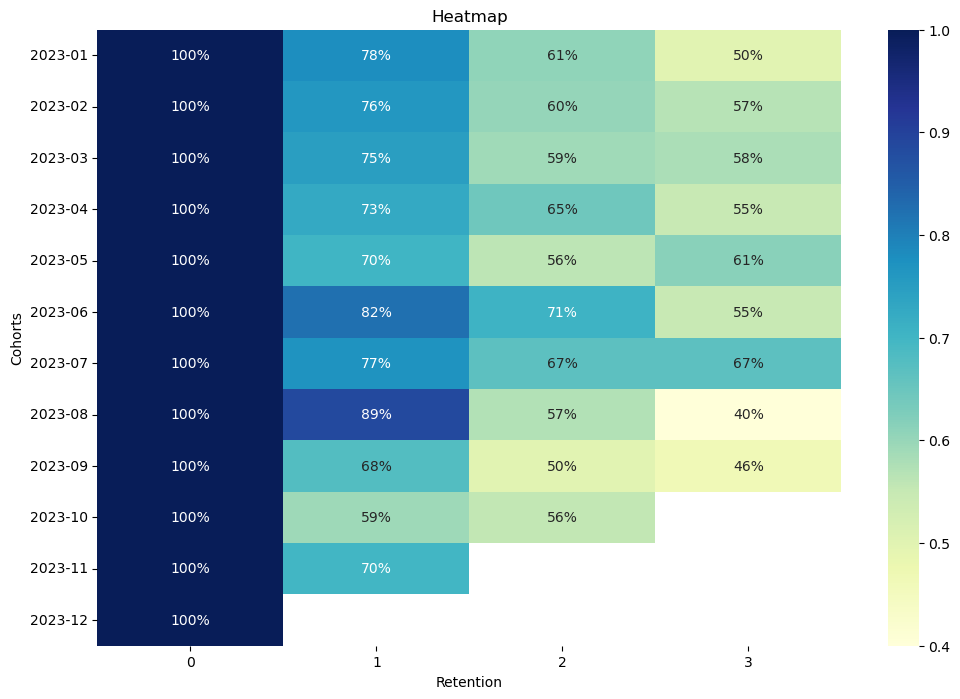

In [160]:
plt.figure(figsize = (12, 8))
sns.heatmap(retention_table.iloc[:,:4], annot=True, fmt = ".0%", cmap = 'YlGnBu')
plt.xlabel('Retention')
plt.ylabel('Cohorts')
plt.title('Heatmap')
plt.show()